In [ ]:
# LSA EXTRACTIVE SUMMARISATION
# 1, 3, 5, 7 SENTENCE SUMMARIES
# FULL DATASET
# SAVE CSV FILES + EVALUATION
# =========================

!pip install pandas numpy nltk scikit-learn rouge-score

import re
import time
import numpy as np
import pandas as pd
import nltk

from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from rouge_score import rouge_scorer

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

# -------------------------
# 1. LOAD DATASET
# -------------------------
DATA_PATH = "/content/IMDB Dataset.csv"

df = pd.read_csv(DATA_PATH)
print("Original dataset shape:", df.shape)
display(df.head())

# -------------------------
# 2. PREPROCESSING
# -------------------------
def clean_text(text):
    text = str(text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df = df.dropna(subset=["review", "sentiment"]).drop_duplicates().reset_index(drop=True)
df["clean_text"] = df["review"].apply(clean_text)
df["label"] = df["sentiment"].map({"positive": 1, "negative": 0})

print("\nCleaned dataset shape:", df.shape)
print("\nLabel distribution:")
print(df["label"].value_counts())

# -------------------------
# 3. TRAIN / VALIDATION / TEST SPLIT
# -------------------------
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df["clean_text"],
    df["label"],
    test_size=0.3,
    stratify=df["label"],
    random_state=42
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.5,
    stratify=temp_labels,
    random_state=42
)

train_texts = train_texts.tolist()
val_texts = val_texts.tolist()
test_texts = test_texts.tolist()

train_labels = train_labels.tolist()
val_labels = val_labels.tolist()
test_labels = test_labels.tolist()

print("\nSplit sizes:")
print("Train:", len(train_texts))
print("Validation:", len(val_texts))
print("Test:", len(test_texts))

# -------------------------
# 4. FULL DATASET
# -------------------------
subset_fraction = 1.0

train_size = int(len(train_texts) * subset_fraction)
val_size = int(len(val_texts) * subset_fraction)
test_size = int(len(test_texts) * subset_fraction)

train_subset = train_texts[:train_size]
val_subset = val_texts[:val_size]
test_subset = test_texts[:test_size]

train_subset_labels = train_labels[:train_size]
val_subset_labels = val_labels[:val_size]
test_subset_labels = test_labels[:test_size]

print("\nSubset sizes:")
print("Train subset:", len(train_subset))
print("Validation subset:", len(val_subset))
print("Test subset:", len(test_subset))

# -------------------------
# 5. LSA SUMMARY FUNCTION
# Generate 1,3,5,7 in one pass
# -------------------------
def lsa_summaries_all(text, ks=[1, 3, 5, 7]):
    sentences = sent_tokenize(str(text))

    if len(sentences) == 0:
        return {k: "" for k in ks}

    if len(sentences) == 1:
        return {k: sentences[0] for k in ks}

    try:
        vectorizer = TfidfVectorizer(stop_words="english")
        X = vectorizer.fit_transform(sentences)

        if X.shape[0] < 2 or X.shape[1] < 2:
            return {k: " ".join(sentences[:min(k, len(sentences))]) for k in ks}

        svd = TruncatedSVD(n_components=1, random_state=42)
        sentence_vectors = svd.fit_transform(X)
        scores = sentence_vectors.flatten()

        ranked_indices = np.argsort(scores)[::-1]

        results = {}
        for k in ks:
            top_k = ranked_indices[:min(k, len(sentences))]
            top_k_sorted = sorted(top_k)
            results[k] = " ".join([sentences[i] for i in top_k_sorted])

        return results

    except Exception:
        return {k: " ".join(sentences[:min(k, len(sentences))]) for k in ks}

# -------------------------
# 6. GENERATE SUMMARIES
# -------------------------
def generate_split_summaries(texts, labels, split_name):
    summaries_1 = []
    summaries_3 = []
    summaries_5 = []
    summaries_7 = []

    start_time = time.time()

    for i, text in enumerate(texts):
        result = lsa_summaries_all(text, ks=[1, 3, 5, 7])
        summaries_1.append(result[1])
        summaries_3.append(result[3])
        summaries_5.append(result[5])
        summaries_7.append(result[7])

        if (i + 1) % 5000 == 0:
            print(f"{split_name}: processed {i+1}/{len(texts)} documents")

    generation_time = time.time() - start_time
    print(f"\n{split_name} summary generation time (seconds):", round(generation_time, 2))

    df_1 = pd.DataFrame({
        "summary_text": summaries_1,
        "label": labels
    })
    df_3 = pd.DataFrame({
        "summary_text": summaries_3,
        "label": labels
    })
    df_5 = pd.DataFrame({
        "summary_text": summaries_5,
        "label": labels
    })
    df_7 = pd.DataFrame({
        "summary_text": summaries_7,
        "label": labels
    })

    df_1.to_csv(f"/content/{split_name}_lsa_1_sentence.csv", index=False)
    df_3.to_csv(f"/content/{split_name}_lsa_3_sentences.csv", index=False)
    df_5.to_csv(f"/content/{split_name}_lsa_5_sentences.csv", index=False)
    df_7.to_csv(f"/content/{split_name}_lsa_7_sentences.csv", index=False)

    print(f"Saved /content/{split_name}_lsa_1_sentence.csv")
    print(f"Saved /content/{split_name}_lsa_3_sentences.csv")
    print(f"Saved /content/{split_name}_lsa_5_sentences.csv")
    print(f"Saved /content/{split_name}_lsa_7_sentences.csv")

    return df_1, df_3, df_5, df_7, generation_time

# -------------------------
# 7. RUN SUMMARY GENERATION
# -------------------------
train_1, train_3, train_5, train_7, train_time = generate_split_summaries(
    train_subset, train_subset_labels, "train"
)

val_1, val_3, val_5, val_7, val_time = generate_split_summaries(
    val_subset, val_subset_labels, "val"
)

test_1, test_3, test_5, test_7, test_time = generate_split_summaries(
    test_subset, test_subset_labels, "test"
)

# -------------------------
# 8. SHOW SAMPLE OUTPUT
# -------------------------
if len(train_subset) > 0:
    print("\n================ SAMPLE ================\n")
    print("Original text:\n")
    print(train_subset[0][:700])

    print("\n1-sentence summary:\n")
    print(train_1.iloc[0]["summary_text"][:700])

    print("\n3-sentence summary:\n")
    print(train_3.iloc[0]["summary_text"][:700])

    print("\n5-sentence summary:\n")
    print(train_5.iloc[0]["summary_text"][:700])

    print("\n7-sentence summary:\n")
    print(train_7.iloc[0]["summary_text"][:700])

# -------------------------
# 9. EVALUATION FUNCTION
# Compression + ROUGE + BLEU
# -------------------------
def evaluate_extractive_summaries(original_texts, summary_texts, dataset_name):
    original_word_counts = []
    summary_word_counts = []
    original_sentence_counts = []
    summary_sentence_counts = []

    rouge1_scores = []
    rouge2_scores = []
    rougel_scores = []
    bleu_scores = []

    scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)
    smoothie = SmoothingFunction().method1

    for original, summary in zip(original_texts, summary_texts):
        original = str(original)
        summary = str(summary)

        orig_words = len(word_tokenize(original))
        summ_words = len(word_tokenize(summary))
        orig_sents = len(sent_tokenize(original))
        summ_sents = len(sent_tokenize(summary))

        original_word_counts.append(orig_words)
        summary_word_counts.append(summ_words)
        original_sentence_counts.append(orig_sents)
        summary_sentence_counts.append(summ_sents)

        try:
            scores = scorer.score(original, summary)
            rouge1_scores.append(scores["rouge1"].fmeasure)
            rouge2_scores.append(scores["rouge2"].fmeasure)
            rougel_scores.append(scores["rougeL"].fmeasure)
        except Exception:
            rouge1_scores.append(np.nan)
            rouge2_scores.append(np.nan)
            rougel_scores.append(np.nan)

        try:
            reference = [word_tokenize(original)]
            candidate = word_tokenize(summary)
            bleu = sentence_bleu(reference, candidate, smoothing_function=smoothie)
            bleu_scores.append(bleu)
        except Exception:
            bleu_scores.append(np.nan)

    avg_original_words = np.mean(original_word_counts)
    avg_summary_words = np.mean(summary_word_counts)
    avg_original_sentences = np.mean(original_sentence_counts)
    avg_summary_sentences = np.mean(summary_sentence_counts)

    word_compression_ratio = avg_summary_words / avg_original_words if avg_original_words > 0 else np.nan
    sentence_compression_ratio = avg_summary_sentences / avg_original_sentences if avg_original_sentences > 0 else np.nan

    avg_rouge1 = np.nanmean(rouge1_scores)
    avg_rouge2 = np.nanmean(rouge2_scores)
    avg_rougel = np.nanmean(rougel_scores)
    avg_bleu = np.nanmean(bleu_scores)

    print("\n================================")
    print("EVALUATION:", dataset_name)
    print("================================")
    print("Average Original Words:", round(avg_original_words, 2))
    print("Average Summary Words:", round(avg_summary_words, 2))
    print("Average Original Sentences:", round(avg_original_sentences, 2))
    print("Average Summary Sentences:", round(avg_summary_sentences, 2))
    print("Word Compression Ratio:", round(word_compression_ratio, 4))
    print("Sentence Compression Ratio:", round(sentence_compression_ratio, 4))
    print("Average ROUGE-1:", round(avg_rouge1, 4))
    print("Average ROUGE-2:", round(avg_rouge2, 4))
    print("Average ROUGE-L:", round(avg_rougel, 4))
    print("Average BLEU:", round(avg_bleu, 4))

    return {
        "Dataset": dataset_name,
        "Avg Original Words": round(avg_original_words, 2),
        "Avg Summary Words": round(avg_summary_words, 2),
        "Avg Original Sentences": round(avg_original_sentences, 2),
        "Avg Summary Sentences": round(avg_summary_sentences, 2),
        "Word Compression Ratio": round(word_compression_ratio, 4),
        "Sentence Compression Ratio": round(sentence_compression_ratio, 4),
        "ROUGE-1": round(avg_rouge1, 4),
        "ROUGE-2": round(avg_rouge2, 4),
        "ROUGE-L": round(avg_rougel, 4),
        "BLEU": round(avg_bleu, 4)
    }

# -------------------------
# 10. RUN EVALUATION
# -------------------------
evaluation_results = []

evaluation_results.append(evaluate_extractive_summaries(train_subset, train_1["summary_text"], "train_1_sentence"))
evaluation_results.append(evaluate_extractive_summaries(train_subset, train_3["summary_text"], "train_3_sentences"))
evaluation_results.append(evaluate_extractive_summaries(train_subset, train_5["summary_text"], "train_5_sentences"))
evaluation_results.append(evaluate_extractive_summaries(train_subset, train_7["summary_text"], "train_7_sentences"))

evaluation_results.append(evaluate_extractive_summaries(val_subset, val_1["summary_text"], "val_1_sentence"))
evaluation_results.append(evaluate_extractive_summaries(val_subset, val_3["summary_text"], "val_3_sentences"))
evaluation_results.append(evaluate_extractive_summaries(val_subset, val_5["summary_text"], "val_5_sentences"))
evaluation_results.append(evaluate_extractive_summaries(val_subset, val_7["summary_text"], "val_7_sentences"))

evaluation_results.append(evaluate_extractive_summaries(test_subset, test_1["summary_text"], "test_1_sentence"))
evaluation_results.append(evaluate_extractive_summaries(test_subset, test_3["summary_text"], "test_3_sentences"))
evaluation_results.append(evaluate_extractive_summaries(test_subset, test_5["summary_text"], "test_5_sentences"))
evaluation_results.append(evaluate_extractive_summaries(test_subset, test_7["summary_text"], "test_7_sentences"))

evaluation_df = pd.DataFrame(evaluation_results)
evaluation_df.to_csv("/content/lsa_extractive_summary_evaluation.csv", index=False)

print("\nSaved evaluation results:")
print("/content/lsa_extractive_summary_evaluation.csv")
display(evaluation_df)

print("\nAll LSA summary CSV files generated successfully.")

  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=ea19565148235ba5c5a19d781083a6e48c8ff16da8f6760344d06489140c5283
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Original dataset shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive



Cleaned dataset shape: (49582, 4)

Label distribution:
label
1    24884
0    24698
Name: count, dtype: int64

Split sizes:
Train: 34707
Validation: 7437
Test: 7438

Subset sizes:
Train subset: 34707
Validation subset: 7437
Test subset: 7438
train: processed 5000/34707 documents
train: processed 10000/34707 documents
train: processed 15000/34707 documents
train: processed 20000/34707 documents
train: processed 25000/34707 documents


/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_truncated_svd.py:273: RuntimeWarning: invalid value encountered in divide
  self.explained_variance_ratio_ = exp_var / full_var


train: processed 30000/34707 documents

train summary generation time (seconds): 164.68
Saved /content/train_lsa_1_sentence.csv
Saved /content/train_lsa_3_sentences.csv
Saved /content/train_lsa_5_sentences.csv
Saved /content/train_lsa_7_sentences.csv
val: processed 5000/7437 documents

val summary generation time (seconds): 28.6
Saved /content/val_lsa_1_sentence.csv
Saved /content/val_lsa_3_sentences.csv
Saved /content/val_lsa_5_sentences.csv
Saved /content/val_lsa_7_sentences.csv
test: processed 5000/7438 documents

test summary generation time (seconds): 29.81
Saved /content/test_lsa_1_sentence.csv
Saved /content/test_lsa_3_sentences.csv
Saved /content/test_lsa_5_sentences.csv
Saved /content/test_lsa_7_sentences.csv

================ SAMPLE ================

Original text:

I work in a library and expected to like this movie when it came out 5 years ago. Well I liked Parker Posey a lot (she's a wonderful actress) and Omar Townsend was really cute as her boyfriend (he couldn't act but

,Dataset,Avg Original Words,Avg Summary Words,Avg Original Sentences,Avg Summary Sentences,Word Compression Ratio,Sentence Compression Ratio,ROUGE-1,ROUGE-2,ROUGE-L,BLEU
0,train_1_sentence,265.46,25.23,12.37,1.01,0.0951,0.0819,0.2172,0.2089,0.2172,0.0336
1,train_3_sentences,265.46,71.51,12.37,2.98,0.2694,0.2409,0.5027,0.4898,0.5027,0.2293
2,train_5_sentences,265.46,115.27,12.37,4.84,0.4342,0.3912,0.6903,0.6786,0.6903,0.4682
3,train_7_sentences,265.46,151.05,12.37,6.47,0.5690,0.5228,0.8051,0.7960,0.8051,0.6485
4,val_1_sentence,264.61,25.17,12.34,1.01,0.0951,0.0821,0.2168,0.2084,0.2168,0.0336
5,val_3_sentences,264.61,71.55,12.34,2.98,0.2704,0.2416,0.5050,0.4920,0.5050,0.2337
6,val_5_sentences,264.61,115.02,12.34,4.84,0.4347,0.3919,0.6929,0.6812,0.6929,0.4734
7,val_7_sentences,264.61,150.52,12.34,6.45,0.5688,0.5223,0.8066,0.7976,0.8066,0.6516
8,test_1_sentence,263.14,25.61,12.15,1.01,0.0973,0.0834,0.2204,0.2121,0.2204,0.0339
9,test_3_sentences,263.14,72.35,12.15,2.98,0.2750,0.2454,0.5077,0.4946,0.5077,0.2330



All LSA summary CSV files generated successfully.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
BASE_DIR = "/content/drive/MyDrive/MSc_Project/lsa_extractive_summaries"

Device: Tesla T4
Reading files from: /content/drive/MyDrive/MSc_Project/lsa_extractive_summaries

Checking files...

/content/drive/MyDrive/MSc_Project/lsa_extractive_summaries/train_lsa_1_sentence.csv -> True
/content/drive/MyDrive/MSc_Project/lsa_extractive_summaries/val_lsa_1_sentence.csv -> True
/content/drive/MyDrive/MSc_Project/lsa_extractive_summaries/test_lsa_1_sentence.csv -> True
/content/drive/MyDrive/MSc_Project/lsa_extractive_summaries/train_lsa_3_sentences.csv -> True
/content/drive/MyDrive/MSc_Project/lsa_extractive_summaries/val_lsa_3_sentences.csv -> True
/content/drive/MyDrive/MSc_Project/lsa_extractive_summaries/test_lsa_3_sentences.csv -> True
/content/drive/MyDrive/MSc_Project/lsa_extractive_summaries/train_lsa_5_sentences.csv -> True
/content/drive/MyDrive/MSc_Project/lsa_extractive_summaries/val_lsa_5_sentences.csv -> True
/content/drive/MyDrive/MSc_Project/lsa_extractive_summaries/test_lsa_5_sentences.csv -> True
/content/drive/MyDrive/MSc_Project/lsa_extractive

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.507118,0.488966,0.763211,0.718369,0.868703,0.786416,0.864107
2,0.348561,0.581069,0.785263,0.774916,0.806270,0.790282,0.869557


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


=== RESULTS ===
Accuracy: 0.7806
Precision: 0.7668
Recall: 0.8087
F1: 0.7872
ROC-AUC: 0.8677
Training time (min): 12.28
Training time per epoch (min): 6.14
Inference time (sec): 16.26
Inference latency per sample (ms): 2.1867
Training throughput (samples/sec): 47.11
Inference throughput (samples/sec): 457.31
Peak training GPU memory (MB): 2307.23
Peak inference GPU memory (MB): 1529.46

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Negative       0.80      0.75      0.77      3705
    Positive       0.77      0.81      0.79      3733

    accuracy                           0.78      7438
   macro avg       0.78      0.78      0.78      7438
weighted avg       0.78      0.78      0.78      7438



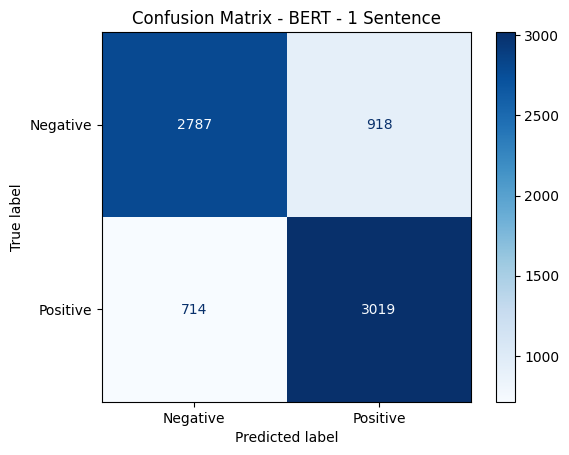

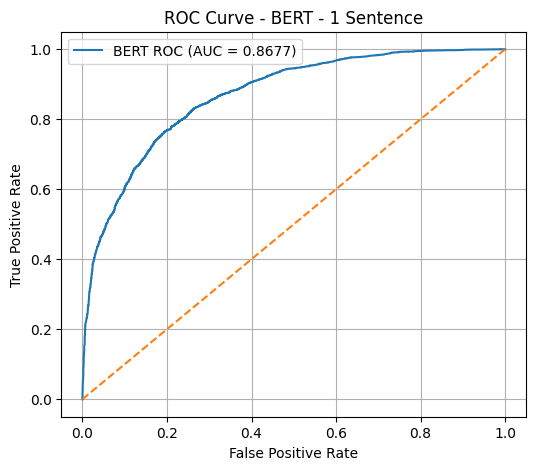

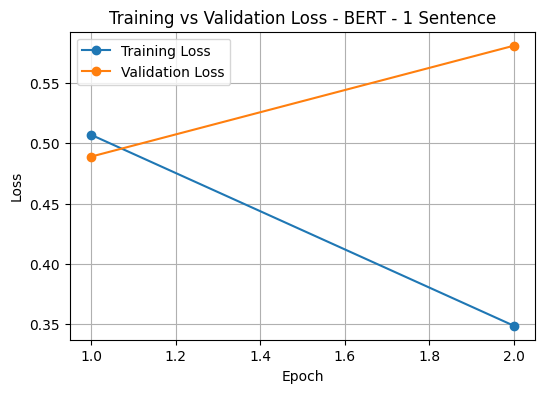


RUNNING: XLNet | Summarised Text | LSA | 1 Sentence


config.json:   0%|          | 0.00/760 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


=== TOKEN / TRUNCATION STATS ===
Train avg tokens before trunc: 31.21
Train avg tokens after trunc: 31.06
Train truncation %: 0.18
Validation avg tokens after trunc: 30.89
Test avg tokens after trunc: 31.46
Test truncation %: 0.2


...

XLNetForSequenceClassification LOAD REPORT from: xlnet-base-cased
Key                             | Status     | 
--------------------------------+------------+-
lm_loss.bias                    | UNEXPECTED | 
lm_loss.weight                  | UNEXPECTED | 
sequence_summary.summary.weight | MISSING    | 
sequence_summary.summary.bias   | MISSING    | 
logits_proj.weight              | MISSING    | 
logits_proj.bias                | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.515889,0.482624,0.776388,0.730761,0.877814,0.797565,0.873478
2,0.383869,0.545386,0.792658,0.779479,0.818328,0.798431,0.878004


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


=== RESULTS ===
Accuracy: 0.7939
Precision: 0.779
Recall: 0.8227
F1: 0.8003
ROC-AUC: 0.8797
Training time (min): 16.67
Training time per epoch (min): 8.33
Inference time (sec): 25.1
Inference latency per sample (ms): 3.374
Training throughput (samples/sec): 34.71
Inference throughput (samples/sec): 296.38
Peak training GPU memory (MB): 3188.45
Peak inference GPU memory (MB): 1751.17

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Negative       0.81      0.76      0.79      3705
    Positive       0.78      0.82      0.80      3733

    accuracy                           0.79      7438
   macro avg       0.79      0.79      0.79      7438
weighted avg       0.79      0.79      0.79      7438



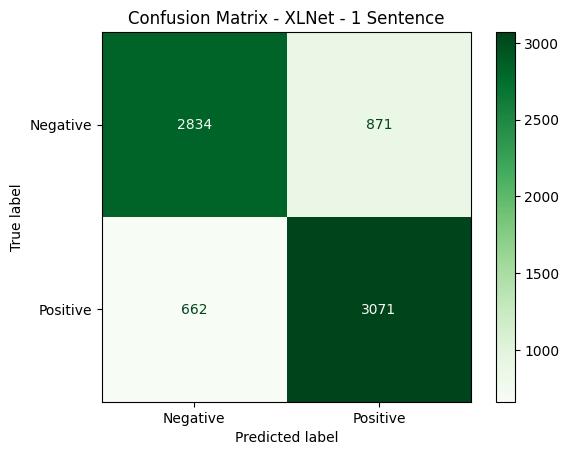

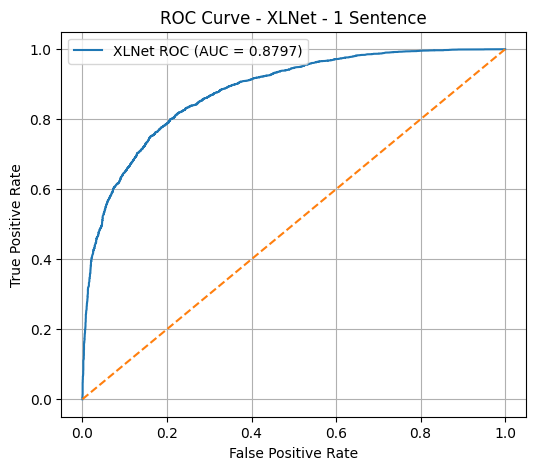

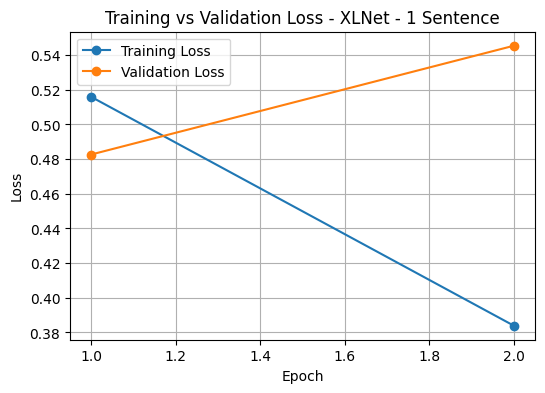


RUNNING: BERT | Summarised Text | LSA | 3 Sentences


Token indices sequence length is longer than the specified maximum sequence length for this model (1113 > 512). Running this sequence through the model will result in indexing errors



=== TOKEN / TRUNCATION STATS ===
Train avg tokens before trunc: 80.98
Train avg tokens after trunc: 80.51
Train truncation %: 0.62
Validation avg tokens after trunc: 80.64
Test avg tokens after trunc: 81.39
Test truncation %: 0.74


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.385962,0.309074,0.870378,0.860042,0.885852,0.872756,0.946830
2,0.242152,0.438881,0.877235,0.874967,0.881297,0.878120,0.949682


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


=== RESULTS ===
Accuracy: 0.87
Precision: 0.8686
Recall: 0.873
F1: 0.8708
ROC-AUC: 0.9461
Training time (min): 15.13
Training time per epoch (min): 7.56
Inference time (sec): 21.39
Inference latency per sample (ms): 2.8761
Training throughput (samples/sec): 38.24
Inference throughput (samples/sec): 347.7
Peak training GPU memory (MB): 2310.4
Peak inference GPU memory (MB): 1528.45

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Negative       0.87      0.87      0.87      3705
    Positive       0.87      0.87      0.87      3733

    accuracy                           0.87      7438
   macro avg       0.87      0.87      0.87      7438
weighted avg       0.87      0.87      0.87      7438



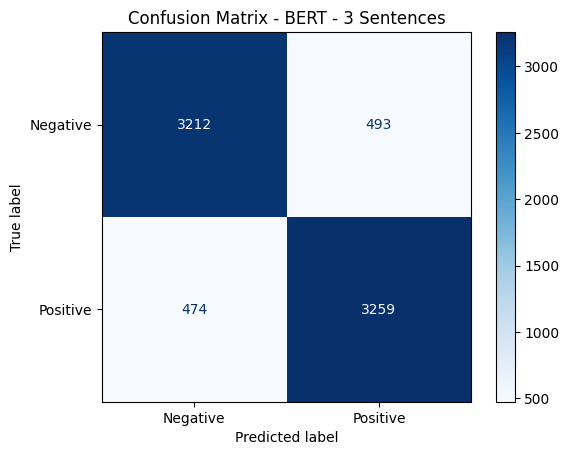

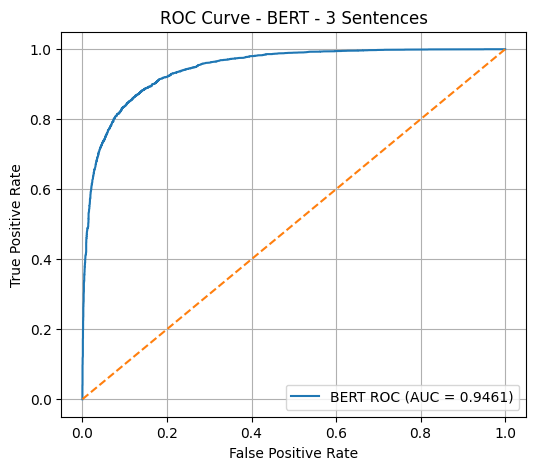

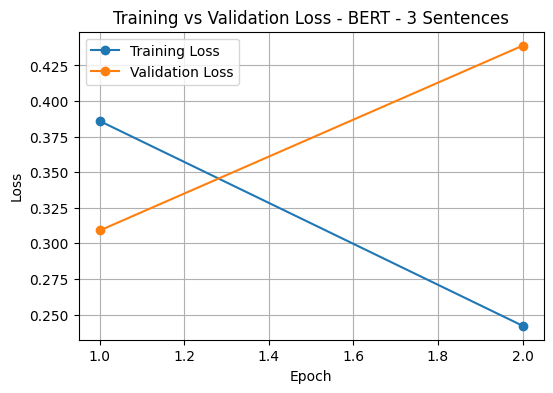


RUNNING: XLNet | Summarised Text | LSA | 3 Sentences

=== TOKEN / TRUNCATION STATS ===
Train avg tokens before trunc: 84.41
Train avg tokens after trunc: 83.8
Train truncation %: 0.82
Validation avg tokens after trunc: 83.88
Test avg tokens after trunc: 84.77
Test truncation %: 1.04


Loading weights:   0%|          | 0/206 [00:00<?, ?it/s]

XLNetForSequenceClassification LOAD REPORT from: xlnet-base-cased
Key                             | Status     | 
--------------------------------+------------+-
lm_loss.bias                    | UNEXPECTED | 
lm_loss.weight                  | UNEXPECTED | 
sequence_summary.summary.weight | MISSING    | 
sequence_summary.summary.bias   | MISSING    | 
logits_proj.weight              | MISSING    | 
logits_proj.bias                | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.370974,0.330822,0.880866,0.869802,0.896838,0.883113,0.951267
2,0.266393,0.459907,0.884228,0.873731,0.899250,0.886307,0.955503


model.safetensors:   0%|          | 0.00/467M [00:00<?, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


=== RESULTS ===
Accuracy: 0.8807
Precision: 0.87
Recall: 0.8963
F1: 0.883
ROC-AUC: 0.9533
Training time (min): 22.07
Training time per epoch (min): 11.03
Inference time (sec): 42.1
Inference latency per sample (ms): 5.6608
Training throughput (samples/sec): 26.21
Inference throughput (samples/sec): 176.65
Peak training GPU memory (MB): 3177.83
Peak inference GPU memory (MB): 1756.3

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Negative       0.89      0.87      0.88      3705
    Positive       0.87      0.90      0.88      3733

    accuracy                           0.88      7438
   macro avg       0.88      0.88      0.88      7438
weighted avg       0.88      0.88      0.88      7438



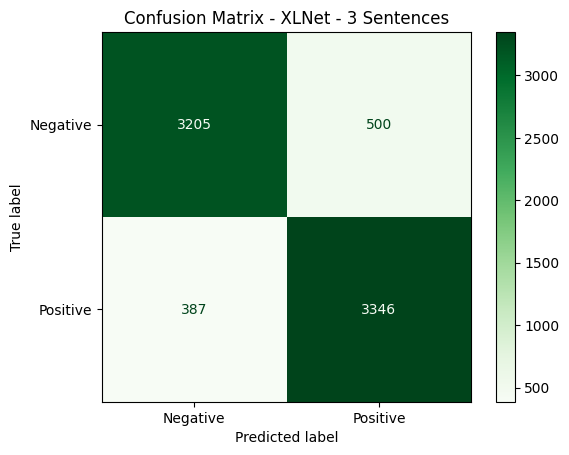

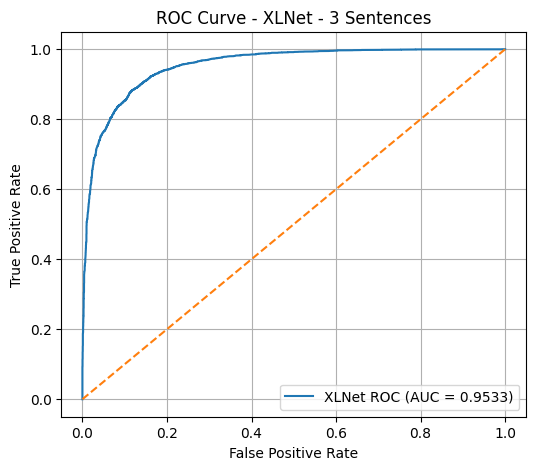

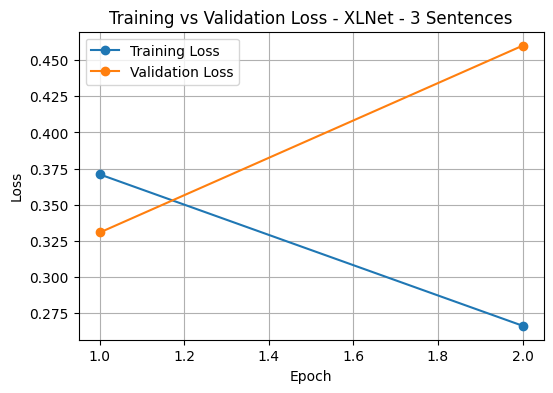


RUNNING: BERT | Summarised Text | LSA | 5 Sentences


Token indices sequence length is longer than the specified maximum sequence length for this model (577 > 512). Running this sequence through the model will result in indexing errors



=== TOKEN / TRUNCATION STATS ===
Train avg tokens before trunc: 129.19
Train avg tokens after trunc: 127.48
Train truncation %: 2.71
Validation avg tokens after trunc: 127.44
Test avg tokens after trunc: 128.54
Test truncation %: 3.0


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.339530,0.289543,0.901035,0.880203,0.929260,0.904067,0.966732
2,0.203578,0.354288,0.910986,0.909989,0.912915,0.911450,0.969922


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


=== RESULTS ===
Accuracy: 0.9043
Precision: 0.8987
Recall: 0.9121
F1: 0.9053
ROC-AUC: 0.9666
Training time (min): 18.58
Training time per epoch (min): 9.29
Inference time (sec): 28.22
Inference latency per sample (ms): 3.7936
Training throughput (samples/sec): 31.14
Inference throughput (samples/sec): 263.61
Peak training GPU memory (MB): 2307.28
Peak inference GPU memory (MB): 1528.2

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Negative       0.91      0.90      0.90      3705
    Positive       0.90      0.91      0.91      3733

    accuracy                           0.90      7438
   macro avg       0.90      0.90      0.90      7438
weighted avg       0.90      0.90      0.90      7438



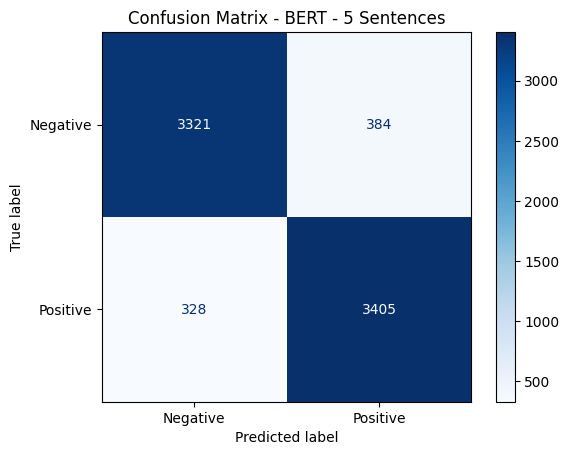

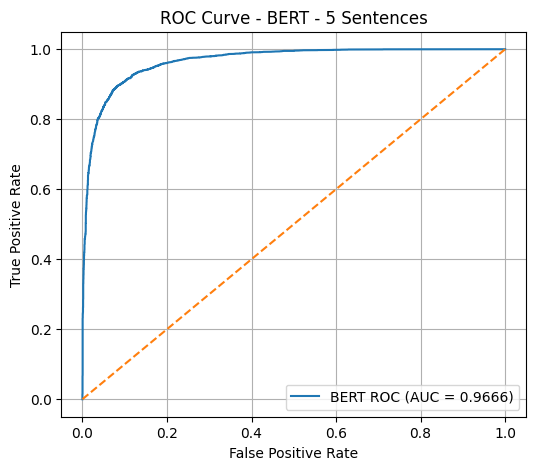

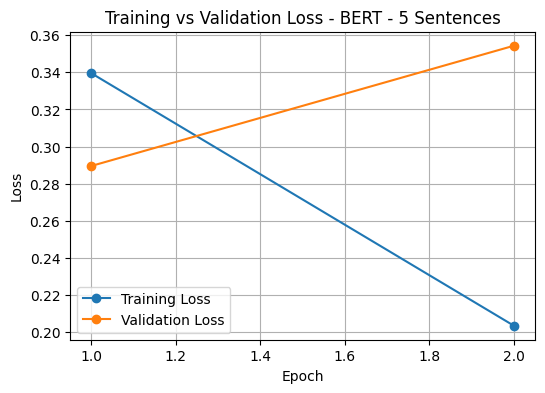


RUNNING: XLNet | Summarised Text | LSA | 5 Sentences

=== TOKEN / TRUNCATION STATS ===
Train avg tokens before trunc: 134.62
Train avg tokens after trunc: 132.34
Train truncation %: 3.57
Validation avg tokens after trunc: 132.26
Test avg tokens after trunc: 133.47
Test truncation %: 3.85


Loading weights:   0%|          | 0/206 [00:00<?, ?it/s]

XLNetForSequenceClassification LOAD REPORT from: xlnet-base-cased
Key                             | Status     | 
--------------------------------+------------+-
lm_loss.bias                    | UNEXPECTED | 
lm_loss.weight                  | UNEXPECTED | 
sequence_summary.summary.weight | MISSING    | 
sequence_summary.summary.bias   | MISSING    | 
logits_proj.weight              | MISSING    | 
logits_proj.bias                | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.333979,0.258190,0.915288,0.893256,0.943998,0.917926,0.972816
2,0.212861,0.345818,0.920264,0.914225,0.928189,0.921154,0.974731


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


=== RESULTS ===
Accuracy: 0.9136
Precision: 0.9068
Recall: 0.9226
F1: 0.9146
ROC-AUC: 0.9725
Training time (min): 27.87
Training time per epoch (min): 13.94
Inference time (sec): 48.05
Inference latency per sample (ms): 6.4604
Training throughput (samples/sec): 20.76
Inference throughput (samples/sec): 154.79
Peak training GPU memory (MB): 3169.45
Peak inference GPU memory (MB): 1754.73

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Negative       0.92      0.90      0.91      3705
    Positive       0.91      0.92      0.91      3733

    accuracy                           0.91      7438
   macro avg       0.91      0.91      0.91      7438
weighted avg       0.91      0.91      0.91      7438



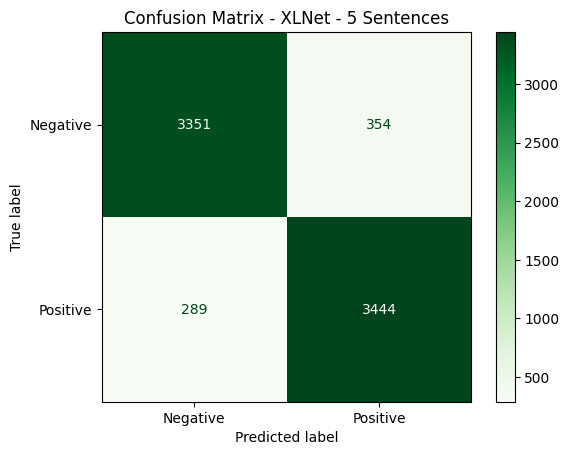

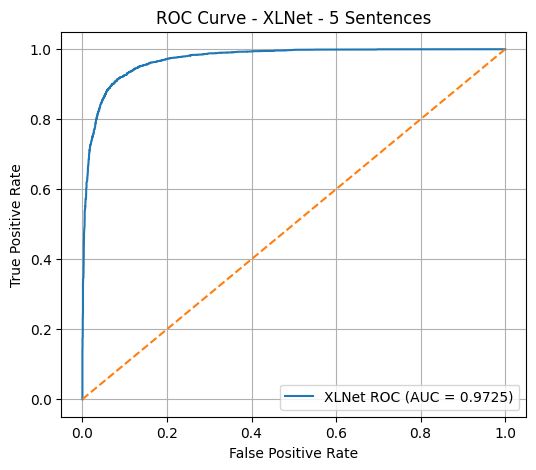

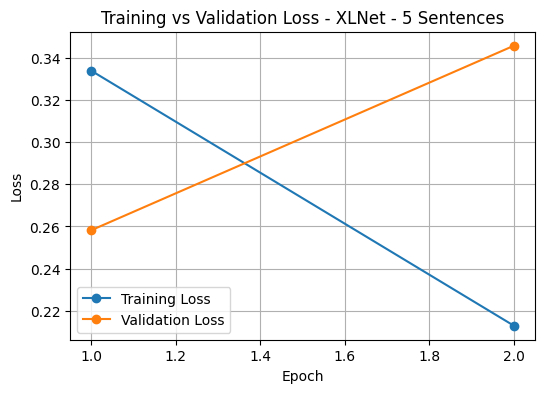


RUNNING: BERT | Summarised Text | LSA | 7 Sentences


Token indices sequence length is longer than the specified maximum sequence length for this model (579 > 512). Running this sequence through the model will result in indexing errors



=== TOKEN / TRUNCATION STATS ===
Train avg tokens before trunc: 168.6
Train avg tokens after trunc: 162.93
Train truncation %: 9.1
Validation avg tokens after trunc: 162.63
Test avg tokens after trunc: 163.55
Test truncation %: 9.46


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.307125,0.261109,0.916230,0.908541,0.926313,0.917341,0.974833
2,0.170955,0.311384,0.922953,0.923118,0.923365,0.923242,0.977409


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


=== RESULTS ===
Accuracy: 0.9213
Precision: 0.9175
Recall: 0.9266
F1: 0.922
ROC-AUC: 0.9761
Training time (min): 20.59
Training time per epoch (min): 10.29
Inference time (sec): 32.86
Inference latency per sample (ms): 4.4185
Training throughput (samples/sec): 28.1
Inference throughput (samples/sec): 226.32
Peak training GPU memory (MB): 2303.34
Peak inference GPU memory (MB): 1526.97

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Negative       0.93      0.92      0.92      3705
    Positive       0.92      0.93      0.92      3733

    accuracy                           0.92      7438
   macro avg       0.92      0.92      0.92      7438
weighted avg       0.92      0.92      0.92      7438



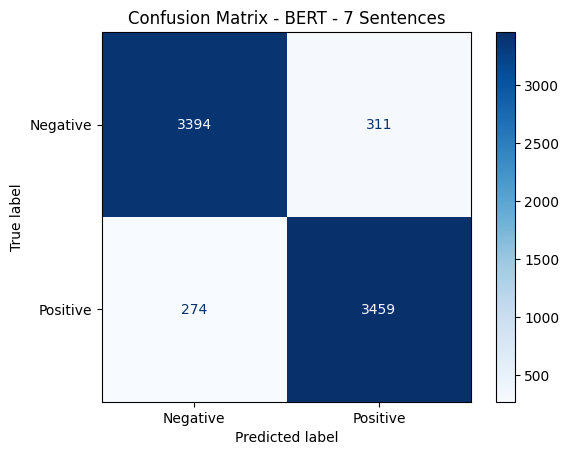

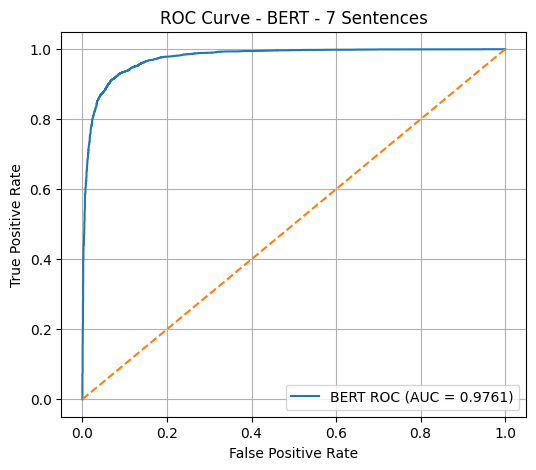

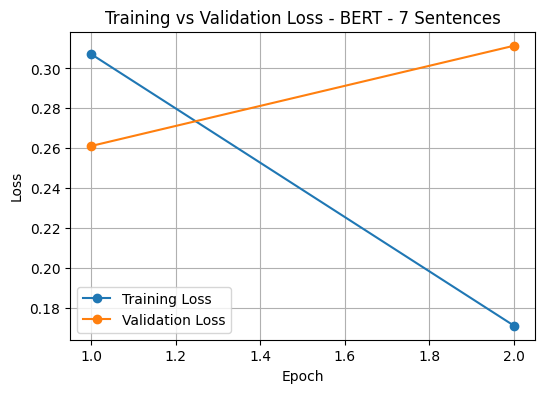


RUNNING: XLNet | Summarised Text | LSA | 7 Sentences

=== TOKEN / TRUNCATION STATS ===
Train avg tokens before trunc: 175.63
Train avg tokens after trunc: 168.28
Train truncation %: 11.21
Validation avg tokens after trunc: 167.95
Test avg tokens after trunc: 168.91
Test truncation %: 11.64


Loading weights:   0%|          | 0/206 [00:00<?, ?it/s]

XLNetForSequenceClassification LOAD REPORT from: xlnet-base-cased
Key                             | Status     | 
--------------------------------+------------+-
lm_loss.bias                    | UNEXPECTED | 
lm_loss.weight                  | UNEXPECTED | 
sequence_summary.summary.weight | MISSING    | 
sequence_summary.summary.bias   | MISSING    | 
logits_proj.weight              | MISSING    | 
logits_proj.bias                | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.304379,0.216333,0.932365,0.931338,0.934084,0.932709,0.980626
2,0.173525,0.299819,0.934651,0.927781,0.943194,0.935424,0.982553


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


=== RESULTS ===
Accuracy: 0.9298
Precision: 0.9231
Recall: 0.9384
F1: 0.9307
ROC-AUC: 0.9815
Training time (min): 31.06
Training time per epoch (min): 15.53
Inference time (sec): 55.3
Inference latency per sample (ms): 7.4351
Training throughput (samples/sec): 18.62
Inference throughput (samples/sec): 134.5
Peak training GPU memory (MB): 3169.95
Peak inference GPU memory (MB): 1754.72

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Negative       0.94      0.92      0.93      3705
    Positive       0.92      0.94      0.93      3733

    accuracy                           0.93      7438
   macro avg       0.93      0.93      0.93      7438
weighted avg       0.93      0.93      0.93      7438



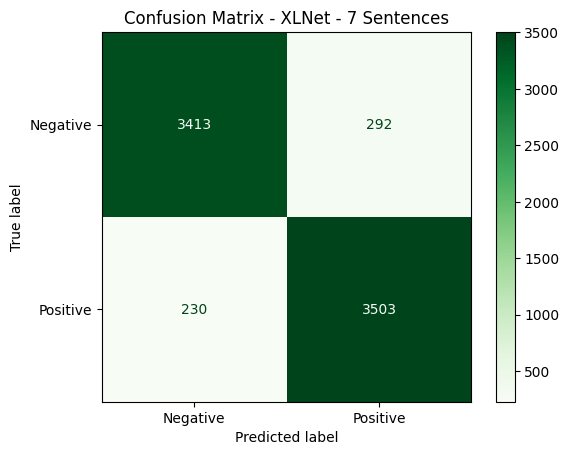

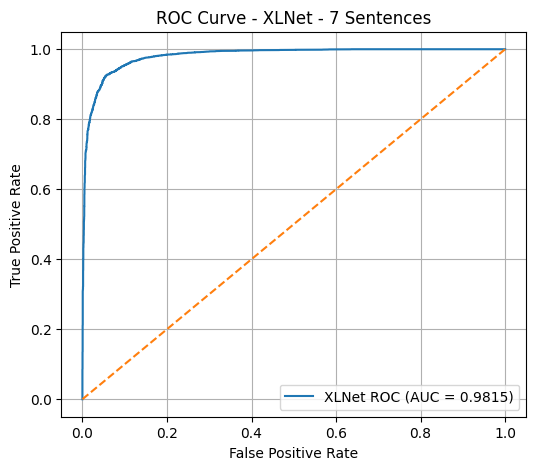

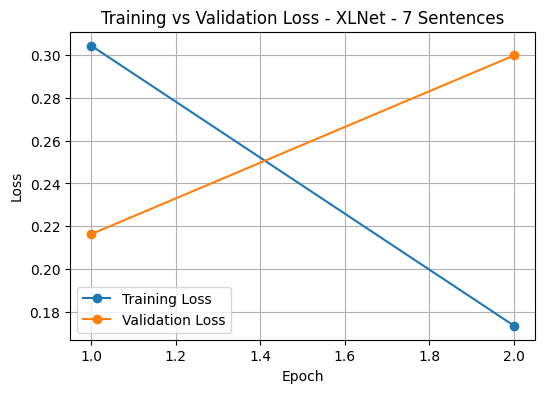


FINAL LSA CLASSIFICATION RESULTS


,Input Type,Summary Method,Summary Length,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Train Samples,...,Test Truncation %,Training Time (min),Training Time per Epoch (min),Inference Time (sec),Inference Latency per Sample (ms),Training Throughput (samples/sec),Inference Throughput (samples/sec),Peak Training GPU Memory (MB),Peak Inference GPU Memory (MB),Device
0,Summarised Text,LSA,1 Sentence,BERT,0.7806,0.7668,0.8087,0.7872,0.8677,34707,...,0.16,12.28,6.14,16.26,2.1867,47.11,457.31,2307.23,1529.46,Tesla T4
1,Summarised Text,LSA,1 Sentence,XLNet,0.7939,0.7790,0.8227,0.8003,0.8797,34707,...,0.20,16.67,8.33,25.10,3.3740,34.71,296.38,3188.45,1751.17,Tesla T4
2,Summarised Text,LSA,3 Sentences,BERT,0.8700,0.8686,0.8730,0.8708,0.9461,34707,...,0.74,15.13,7.56,21.39,2.8761,38.24,347.70,2310.40,1528.45,Tesla T4
3,Summarised Text,LSA,3 Sentences,XLNet,0.8807,0.8700,0.8963,0.8830,0.9533,34707,...,1.04,22.07,11.03,42.10,5.6608,26.21,176.65,3177.83,1756.30,Tesla T4
4,Summarised Text,LSA,5 Sentences,BERT,0.9043,0.8987,0.9121,0.9053,0.9666,34707,...,3.00,18.58,9.29,28.22,3.7936,31.14,263.61,2307.28,1528.20,Tesla T4
5,Summarised Text,LSA,5 Sentences,XLNet,0.9136,0.9068,0.9226,0.9146,0.9725,34707,...,3.85,27.87,13.94,48.05,6.4604,20.76,154.79,3169.45,1754.73,Tesla T4
6,Summarised Text,LSA,7 Sentences,BERT,0.9213,0.9175,0.9266,0.9220,0.9761,34707,...,9.46,20.59,10.29,32.86,4.4185,28.10,226.32,2303.34,1526.97,Tesla T4
7,Summarised Text,LSA,7 Sentences,XLNet,0.9298,0.9231,0.9384,0.9307,0.9815,34707,...,11.64,31.06,15.53,55.30,7.4351,18.62,134.50,3169.95,1754.72,Tesla T4



Saved: /content/drive/MyDrive/MSc_Project/lsa_extractive_summaries/lsa_classification_results.csv


In [ ]:
# =====================================================
# LSA EXTRACTIVE SUMMARY CLASSIFICATION
# READ FROM GOOGLE DRIVE
# MODELS: BERT + XLNet
# INPUTS: 1, 3, 5, 7 SENTENCE SUMMARIES
# =====================================================

!pip install -q pandas numpy matplotlib scikit-learn transformers datasets sentencepiece accelerate torch

import os
import gc
import time
import random
import warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    set_seed
)

warnings.filterwarnings("ignore")

# -------------------------
# REPRODUCIBILITY
# -------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

device_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
print("Device:", device_name)

# -------------------------
# GOOGLE DRIVE PATH
# -------------------------
BASE_DIR = "/content/drive/MyDrive/MSc_Project/lsa_extractive_summaries"
print("Reading files from:", BASE_DIR)

# -------------------------
# DATASET CLASS
# -------------------------
class TextDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

# -------------------------
# METRICS FUNCTION
# -------------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "roc_auc": roc_auc_score(labels, probs)
    }

# -------------------------
# UTILITIES
# -------------------------
def reset_gpu_memory():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

def get_peak_gpu_memory_mb():
    if torch.cuda.is_available():
        return torch.cuda.max_memory_allocated() / (1024 ** 2)
    return None

def get_token_stats(texts, tokenizer, max_length=256, batch_size=512):
    full_lengths = []
    trunc_lengths = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]

        full_batch = tokenizer(
            batch,
            add_special_tokens=True,
            truncation=False,
            padding=False
        )

        trunc_batch = tokenizer(
            batch,
            truncation=True,
            padding=False,
            max_length=max_length
        )

        full_lengths.extend([len(x) for x in full_batch["input_ids"]])
        trunc_lengths.extend([len(x) for x in trunc_batch["input_ids"]])

    truncated_count = sum(1 for x in full_lengths if x > max_length)

    stats = {
        "avg_tokens_before_trunc": float(np.mean(full_lengths)),
        "avg_tokens_after_trunc": float(np.mean(trunc_lengths)),
        "max_tokens_before_trunc": int(np.max(full_lengths)),
        "truncated_count": int(truncated_count),
        "truncation_pct": float(truncated_count / len(full_lengths) * 100)
    }

    trunc_enc = tokenizer(
        texts,
        truncation=True,
        padding=False,
        max_length=max_length
    )

    return stats, trunc_enc

def plot_confusion_matrix(y_true, y_pred, title, cmap):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Negative", "Positive"]
    )
    disp.plot(cmap=cmap)
    plt.title(title)
    plt.show()

def plot_roc_curve(y_true, y_prob, title, label_name):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc_value = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"{label_name} (AUC = {roc_auc_value:.4f})")
    plt.plot([0, 1], [0, 1], "--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_train_val_loss(trainer, title):
    history = trainer.state.log_history
    train_loss = []
    val_loss = []
    train_epochs = []
    val_epochs = []

    for log in history:
        if "loss" in log and "epoch" in log:
            train_loss.append(log["loss"])
            train_epochs.append(log["epoch"])
        if "eval_loss" in log and "epoch" in log:
            val_loss.append(log["eval_loss"])
            val_epochs.append(log["epoch"])

    plt.figure(figsize=(6, 4))
    plt.plot(train_epochs, train_loss, marker="o", label="Training Loss")
    plt.plot(val_epochs, val_loss, marker="o", label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# -------------------------
# LOAD SUMMARY CSV FILES
# -------------------------
def load_summary_split(train_path, val_path, test_path):
    train_df = pd.read_csv(train_path)
    val_df = pd.read_csv(val_path)
    test_df = pd.read_csv(test_path)

    train_texts = train_df["summary_text"].fillna("").astype(str).tolist()
    val_texts = val_df["summary_text"].fillna("").astype(str).tolist()
    test_texts = test_df["summary_text"].fillna("").astype(str).tolist()

    train_labels = train_df["label"].tolist()
    val_labels = val_df["label"].tolist()
    test_labels = test_df["label"].tolist()

    return train_texts, val_texts, test_texts, train_labels, val_labels, test_labels

# -------------------------
# EXPERIMENT FUNCTION
# -------------------------
def run_experiment(model_name, model_label, input_type, summary_method, summary_length,
                   train_texts, val_texts, test_texts,
                   train_labels, val_labels, test_labels,
                   output_dir, max_length=256, batch_size=8):

    print(f"\n{'='*75}")
    print(f"RUNNING: {model_label} | {input_type} | {summary_method} | {summary_length}")
    print(f"{'='*75}")

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token if tokenizer.eos_token is not None else tokenizer.unk_token

    train_stats, train_enc = get_token_stats(train_texts, tokenizer, max_length=max_length)
    val_stats, val_enc = get_token_stats(val_texts, tokenizer, max_length=max_length)
    test_stats, test_enc = get_token_stats(test_texts, tokenizer, max_length=max_length)

    print("\n=== TOKEN / TRUNCATION STATS ===")
    print("Train avg tokens before trunc:", round(train_stats["avg_tokens_before_trunc"], 2))
    print("Train avg tokens after trunc:", round(train_stats["avg_tokens_after_trunc"], 2))
    print("Train truncation %:", round(train_stats["truncation_pct"], 2))
    print("Validation avg tokens after trunc:", round(val_stats["avg_tokens_after_trunc"], 2))
    print("Test avg tokens after trunc:", round(test_stats["avg_tokens_after_trunc"], 2))
    print("Test truncation %:", round(test_stats["truncation_pct"], 2))

    train_dataset = TextDataset(train_enc, train_labels)
    val_dataset = TextDataset(val_enc, val_labels)
    test_dataset = TextDataset(test_enc, test_labels)

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

    if model.config.pad_token_id is None:
        model.config.pad_token_id = tokenizer.pad_token_id

    args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        save_total_limit=2,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=2,
        learning_rate=2e-5,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        fp16=torch.cuda.is_available(),
        report_to="none",
        seed=SEED
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        data_collator=data_collator
    )

    # -------- TRAINING --------
    reset_gpu_memory()
    train_start = time.time()
    trainer.train()
    train_time = time.time() - train_start
    peak_train_mem = get_peak_gpu_memory_mb()

    # -------- INFERENCE --------
    reset_gpu_memory()
    infer_start = time.time()
    pred = trainer.predict(test_dataset)
    infer_time = time.time() - infer_start
    peak_infer_mem = get_peak_gpu_memory_mb()

    y_true = np.array(test_labels)
    y_pred = np.argmax(pred.predictions, axis=1)
    y_prob = torch.softmax(torch.tensor(pred.predictions), dim=1)[:, 1].numpy()

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc_auc_value = roc_auc_score(y_true, y_prob)

    num_train = len(train_dataset)
    num_test = len(test_dataset)

    train_time_per_epoch = train_time / int(args.num_train_epochs)
    train_samples_per_sec = num_train / train_time
    infer_samples_per_sec = num_test / infer_time
    infer_latency_per_sample_ms = (infer_time / num_test) * 1000

    print("\n=== RESULTS ===")
    print("Accuracy:", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall:", round(rec, 4))
    print("F1:", round(f1, 4))
    print("ROC-AUC:", round(roc_auc_value, 4))
    print("Training time (min):", round(train_time / 60, 2))
    print("Training time per epoch (min):", round(train_time_per_epoch / 60, 2))
    print("Inference time (sec):", round(infer_time, 2))
    print("Inference latency per sample (ms):", round(infer_latency_per_sample_ms, 4))
    print("Training throughput (samples/sec):", round(train_samples_per_sec, 2))
    print("Inference throughput (samples/sec):", round(infer_samples_per_sec, 2))
    print("Peak training GPU memory (MB):", round(peak_train_mem, 2) if peak_train_mem is not None else "N/A")
    print("Peak inference GPU memory (MB):", round(peak_infer_mem, 2) if peak_infer_mem is not None else "N/A")

    print("\n=== CLASSIFICATION REPORT ===")
    print(classification_report(
        y_true,
        y_pred,
        target_names=["Negative", "Positive"],
        zero_division=0
    ))

    plot_confusion_matrix(
        y_true, y_pred,
        f"Confusion Matrix - {model_label} - {summary_length}",
        "Blues" if model_label == "BERT" else "Greens"
    )

    plot_roc_curve(
        y_true, y_prob,
        f"ROC Curve - {model_label} - {summary_length}",
        f"{model_label} ROC"
    )

    plot_train_val_loss(
        trainer,
        f"Training vs Validation Loss - {model_label} - {summary_length}"
    )

    results = {
        "Input Type": input_type,
        "Summary Method": summary_method,
        "Summary Length": summary_length,
        "Model": model_label,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1": round(f1, 4),
        "ROC-AUC": round(roc_auc_value, 4),
        "Train Samples": num_train,
        "Test Samples": num_test,
        "Avg Train Tokens Before Trunc": round(train_stats["avg_tokens_before_trunc"], 2),
        "Avg Train Tokens After Trunc": round(train_stats["avg_tokens_after_trunc"], 2),
        "Avg Test Tokens Before Trunc": round(test_stats["avg_tokens_before_trunc"], 2),
        "Avg Test Tokens After Trunc": round(test_stats["avg_tokens_after_trunc"], 2),
        "Test Truncation %": round(test_stats["truncation_pct"], 2),
        "Training Time (min)": round(train_time / 60, 2),
        "Training Time per Epoch (min)": round(train_time_per_epoch / 60, 2),
        "Inference Time (sec)": round(infer_time, 2),
        "Inference Latency per Sample (ms)": round(infer_latency_per_sample_ms, 4),
        "Training Throughput (samples/sec)": round(train_samples_per_sec, 2),
        "Inference Throughput (samples/sec)": round(infer_samples_per_sec, 2),
        "Peak Training GPU Memory (MB)": round(peak_train_mem, 2) if peak_train_mem is not None else None,
        "Peak Inference GPU Memory (MB)": round(peak_infer_mem, 2) if peak_infer_mem is not None else None,
        "Device": device_name
    }

    del model, trainer, train_dataset, val_dataset, test_dataset
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return results

# -------------------------
# FILE CONFIGURATION
# -------------------------
summary_configs = [
    {
        "summary_length": "1 Sentence",
        "train_path": f"{BASE_DIR}/train_lsa_1_sentence.csv",
        "val_path": f"{BASE_DIR}/val_lsa_1_sentence.csv",
        "test_path": f"{BASE_DIR}/test_lsa_1_sentence.csv",
    },
    {
        "summary_length": "3 Sentences",
        "train_path": f"{BASE_DIR}/train_lsa_3_sentences.csv",
        "val_path": f"{BASE_DIR}/val_lsa_3_sentences.csv",
        "test_path": f"{BASE_DIR}/test_lsa_3_sentences.csv",
    },
    {
        "summary_length": "5 Sentences",
        "train_path": f"{BASE_DIR}/train_lsa_5_sentences.csv",
        "val_path": f"{BASE_DIR}/val_lsa_5_sentences.csv",
        "test_path": f"{BASE_DIR}/test_lsa_5_sentences.csv",
    },
    {
        "summary_length": "7 Sentences",
        "train_path": f"{BASE_DIR}/train_lsa_7_sentences.csv",
        "val_path": f"{BASE_DIR}/val_lsa_7_sentences.csv",
        "test_path": f"{BASE_DIR}/test_lsa_7_sentences.csv",
    }
]

# -------------------------
# CHECK FILES EXIST
# -------------------------
print("\nChecking files...\n")
for config in summary_configs:
    for key in ["train_path", "val_path", "test_path"]:
        print(config[key], "->", os.path.exists(config[key]))

# -------------------------
# RUN ALL EXPERIMENTS
# -------------------------
all_results = []

for config in summary_configs:
    train_texts, val_texts, test_texts, train_labels, val_labels, test_labels = load_summary_split(
        config["train_path"],
        config["val_path"],
        config["test_path"]
    )

    bert_result = run_experiment(
        model_name="bert-base-uncased",
        model_label="BERT",
        input_type="Summarised Text",
        summary_method="LSA",
        summary_length=config["summary_length"],
        train_texts=train_texts,
        val_texts=val_texts,
        test_texts=test_texts,
        train_labels=train_labels,
        val_labels=val_labels,
        test_labels=test_labels,
        output_dir=f"/content/bert_lsa_{config['summary_length'].replace(' ', '_').lower()}",
        max_length=256,
        batch_size=8
    )
    all_results.append(bert_result)

    xlnet_result = run_experiment(
        model_name="xlnet-base-cased",
        model_label="XLNet",
        input_type="Summarised Text",
        summary_method="LSA",
        summary_length=config["summary_length"],
        train_texts=train_texts,
        val_texts=val_texts,
        test_texts=test_texts,
        train_labels=train_labels,
        val_labels=val_labels,
        test_labels=test_labels,
        output_dir=f"/content/xlnet_lsa_{config['summary_length'].replace(' ', '_').lower()}",
        max_length=256,
        batch_size=8
    )
    all_results.append(xlnet_result)

# -------------------------
# SAVE FINAL RESULTS
# -------------------------
results_df = pd.DataFrame(all_results)

print("\nFINAL LSA CLASSIFICATION RESULTS")
display(results_df)

results_df.to_csv(f"{BASE_DIR}/lsa_classification_results.csv", index=False)
print(f"\nSaved: {BASE_DIR}/lsa_classification_results.csv")